In [1]:
import pandas as pd
import numpy as np
import re

file_path = "C:/Users/rohan/Downloads/TOUCHABLE CHAPA Chapter 40B Application Data 2021-2023 & 10_2023-05_2025.xlsx"

# Load the 23–25 sheet only
df = pd.read_excel(file_path, sheet_name="23-25_data_updated")

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("/", "_").str.replace("?", "")

print("✅ Data loaded:", df.shape)
df.head()


✅ Data loaded: (1359, 29)


,id_number,submission_date,submission_time,application_property,application_city_town,application_st_address,application_unit,source_new,age,race_combination_normalized,...,fthb_class,unique_id,street_address,city,state,zip,match_status,match_type,matched_address,msa
0,101,2024-05-28,13:31:01,"14 Caspian Way, Unit 23 ~ Leominster",Leominster,14 Caspian Way,unit 23,MyMassHome,65.0,White,...,No,497,14 Caspian Way,Leominster,MA,NaN,Match,Non_Exact,"14 CASPIAN ST, LEOMINSTER, MA, 01453","Worcester, MA"
1,101,2024-07-21,17:33:34,1 Millbrook Lane Unit 213 ~ Wakefield,Wakefield,1 Millbrook Lane Unit 213,NaN,MyMassHome,65.0,White,...,No,696,1 Millbrook Lane Unit 213,Wakefield,MA,NaN,Match,Exact,"1 MILLBROOK LN, WAKEFIELD, MA, 01880","Boston-Cambridge-Newton, MA-NH"
2,1595,2024-02-05,13:37:00,"11 Indian Woods Way, Unit 11 ~ Canton",Canton,11 Indian Woods Way,unit 11,City of Boston Metrolist,56.0,Black or African American,...,Yes,175,11 Indian Woods Way,Canton,MA,NaN,Match,Exact,"11 INDIAN WOODS WAY, CANTON, MA, 02021","Boston-Cambridge-Newton, MA-NH"
3,2159,2024-07-22,23:33:59,24 Haywood Circle ~ Mendon,Mendon,24 Haywood Circle,NaN,Zillow/Trulia/Other Website,30.0,Black or African American,...,Yes,706,24 Haywood Circle,Mendon,MA,NaN,Match,Exact,"24 HAYWOOD CIR, MENDON, MA, 01756","Worcester, MA"
4,2685,2024-08-28,10:50:33,"6 Woodman Way, unit 204A ~ Newburyport",Newburyport,6 Woodman Way,unit 204a,Real Estate Agent,58.0,White,...,No,888,6 Woodman Way,Newburyport,MA,NaN,Match,Exact,"6 WOODMAN WAY, NEWBURYPORT, MA, 01950","Boston-Cambridge-Newton, MA-NH"


In [2]:
race_cols = ['race_combination_normalized', 'census_races']
df_race = df[race_cols].copy()
df_race.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1359 entries, 0 to 1358
Data columns (total 2 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   race_combination_normalized  1359 non-null   object
 1   census_races                 1359 non-null   object
dtypes: object(2)
memory usage: 21.4+ KB


In [3]:
def parse_race_string(race_str):
    if pd.isna(race_str):
        return []
    race_str = race_str.lower().strip()
    # Normalize certain phrases before splitting
    race_str = race_str.replace("pacific islander or native hawaiian", "pacific islander or native hawaiian")
    race_str = race_str.replace("native hawaiian or pacific islander", "native hawaiian or pacific islander")
    race_str = race_str.replace("middle eastern or north african", "middle eastern or north african")
    race_str = race_str.replace("black or african american", "black or african american")

    # Now splitting on commas or semicolons
    parts = [p.strip() for p in re.split(r"[,;/]", race_str) if p.strip()]
    return sorted(set(parts))

df['race_list'] = df['race_combination_normalized'].apply(parse_race_string)
df['race_count'] = df['race_list'].apply(len)
df['race_type'] = np.where(df['race_count'] > 1, "Multiracial", "Single Race")

df[['race_combination_normalized', 'race_list', 'race_type']].head(10)



,race_combination_normalized,race_list,race_type
0,White,[white],Single Race
1,White,[white],Single Race
2,Black or African American,[black or african american],Single Race
3,Black or African American,[black or african american],Single Race
4,White,[white],Single Race
5,White,[white],Single Race
6,White,[white],Single Race
7,White,[white],Single Race
8,Native American or Alaskan Native,[native american or alaskan native],Single Race
9,White,[white],Single Race


In [4]:
def canonical_race(race_terms):
    canonical = []
    for term in race_terms:
        if "white" in term:
            canonical.append("White")
        elif "black" in term or "african" in term:
            canonical.append("Black or African American")
        elif "asian" in term:
            canonical.append("Asian")
        elif "hispanic" in term or "latino" in term:
            canonical.append("Hispanic or Latino")
        elif "pacific" in term or "hawaiian" in term:
            canonical.append("Native Hawaiian or Pacific Islander")
        elif "native" in term and "alaskan" in term:
            canonical.append("American Indian or Alaska Native")
        elif "middle eastern" in term or "north african" in term:
            canonical.append("Middle Eastern or North African")
        elif "other" in term or "choose" in term or "missing" in term:
            canonical.append("Other / Prefer not to answer")
    return sorted(set(canonical))

df['race_cleaned'] = df['race_list'].apply(canonical_race)


In [5]:
df[df['race_type'] == "Multiracial"][['race_combination_normalized', 'race_list', 'race_cleaned']].head(10)


,race_combination_normalized,race_list,race_cleaned
50,"Asian, White","[asian, white]","[Asian, White]"
55,"Asian, Pacific Islander or Native Hawaiian","[asian, pacific islander or native hawaiian]","[Asian, Native Hawaiian or Pacific Islander]"
69,"Black or African American, Hispanic or Latino","[black or african american, hispanic or latino]","[Black or African American, Hispanic or Latino]"
95,"Asian, Pacific Islander or Native Hawaiian","[asian, pacific islander or native hawaiian]","[Asian, Native Hawaiian or Pacific Islander]"
96,"Asian, Pacific Islander or Native Hawaiian","[asian, pacific islander or native hawaiian]","[Asian, Native Hawaiian or Pacific Islander]"
102,"Asian, Pacific Islander or Native Hawaiian","[asian, pacific islander or native hawaiian]","[Asian, Native Hawaiian or Pacific Islander]"
103,"Asian, Pacific Islander or Native Hawaiian","[asian, pacific islander or native hawaiian]","[Asian, Native Hawaiian or Pacific Islander]"
119,"Asian, Pacific Islander or Native Hawaiian","[asian, pacific islander or native hawaiian]","[Asian, Native Hawaiian or Pacific Islander]"
135,"Black or African American, Hispanic or Latino","[black or african american, hispanic or latino]","[Black or African American, Hispanic or Latino]"
136,"Black or African American, Hispanic or Latino","[black or african american, hispanic or latino]","[Black or African American, Hispanic or Latino]"


In [6]:
if 'hispanic_latino' not in df.columns:
    df['hispanic_latino'] = 0

df['hispanic_latino'] = np.where(
    df['race_cleaned'].apply(lambda r: "Hispanic or Latino" in r),
    1,
    df['hispanic_latino']
)

print(df['hispanic_latino'].value_counts())


hispanic_latino
0    1157
1     202
Name: count, dtype: int64


In [7]:
unique_races = sorted({race for sublist in df['race_cleaned'] for race in sublist})
print("✅ Unique standardized races:", unique_races)

for race in unique_races:
    col_name = f"race_{race.replace(' ', '_').replace('/', '')}"
    df[col_name] = df['race_cleaned'].apply(lambda x: int(race in x))


✅ Unique standardized races: ['American Indian or Alaska Native', 'Asian', 'Black or African American', 'Hispanic or Latino', 'Native Hawaiian or Pacific Islander', 'Other / Prefer not to answer', 'White']


In [8]:
df[['race_combination_normalized', 'race_cleaned', 'race_type'] + 
   [col for col in df.columns if col.startswith('race_')]].head(10)


,race_combination_normalized,race_cleaned,race_type,race_combination_normalized,race_list,race_count,race_type,race_cleaned,race_American_Indian_or_Alaska_Native,race_Asian,race_Black_or_African_American,race_Hispanic_or_Latino,race_Native_Hawaiian_or_Pacific_Islander,race_Other__Prefer_not_to_answer,race_White
0,White,[White],Single Race,White,[white],1,Single Race,[White],0,0,0,0,0,0,1
1,White,[White],Single Race,White,[white],1,Single Race,[White],0,0,0,0,0,0,1
2,Black or African American,[Black or African American],Single Race,Black or African American,[black or african american],1,Single Race,[Black or African American],0,0,1,0,0,0,0
3,Black or African American,[Black or African American],Single Race,Black or African American,[black or african american],1,Single Race,[Black or African American],0,0,1,0,0,0,0
4,White,[White],Single Race,White,[white],1,Single Race,[White],0,0,0,0,0,0,1
5,White,[White],Single Race,White,[white],1,Single Race,[White],0,0,0,0,0,0,1
6,White,[White],Single Race,White,[white],1,Single Race,[White],0,0,0,0,0,0,1
7,White,[White],Single Race,White,[white],1,Single Race,[White],0,0,0,0,0,0,1
8,Native American or Alaskan Native,[American Indian or Alaska Native],Single Race,Native American or Alaskan Native,[native american or alaskan native],1,Single Race,[American Indian or Alaska Native],1,0,0,0,0,0,0
9,White,[White],Single Race,White,[white],1,Single Race,[White],0,0,0,0,0,0,1


### Race Data Cleaning & Encoding Summary

- **Objective:** Standardize and encode applicant race information from the `race_combination_normalized` column to align with U.S. Census categories.  
- **Steps:**
  1. Parsed raw text into structured lists using an improved `parse_race_string()` to preserve multi-race combinations.
  2. Canonically mapped diverse race labels to seven standardized categories.
  3. Added a `race_type` column to distinguish single-race vs. multiracial applicants.
  4. Created binary indicator (dummy) columns for each race category for future quantitative analysis.
  5. Introduced a `hispanic_latino` dummy variable for ethnicity alignment.
- **Outcome:** A clean, one-hot encoded race dataset suitable for demographic breakdowns, equity analysis, or linking to housing outcomes.


C:\Users\rohan\AppData\Local\Temp\ipykernel_38944\1280317362.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=race_series, order=race_series.value_counts().index, palette="crest")


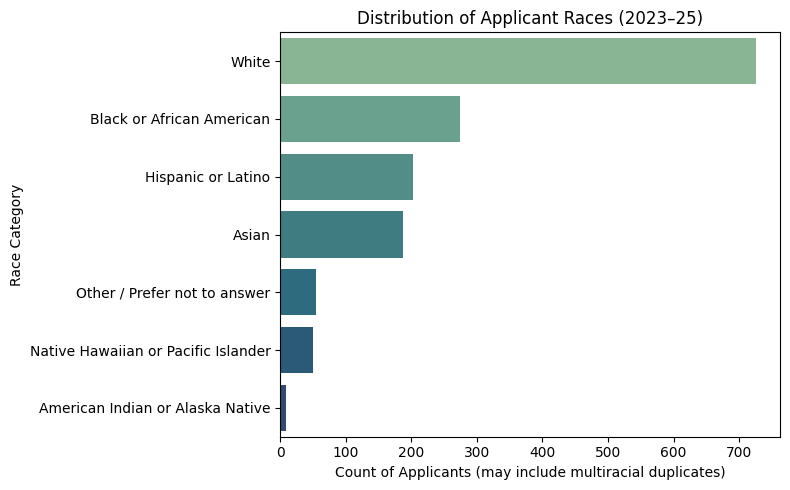

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Flatten the list
race_flat = [r for sublist in df['race_cleaned'] for r in sublist]
race_series = pd.Series(race_flat)

plt.figure(figsize=(8,5))
sns.countplot(y=race_series, order=race_series.value_counts().index, palette="crest")
plt.title("Distribution of Applicant Races (2023–25)")
plt.xlabel("Count of Applicants (may include multiracial duplicates)")
plt.ylabel("Race Category")
plt.tight_layout()
plt.show()


C:\Users\rohan\AppData\Local\Temp\ipykernel_38944\2919899147.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='race_type', data=df, palette='pastel')


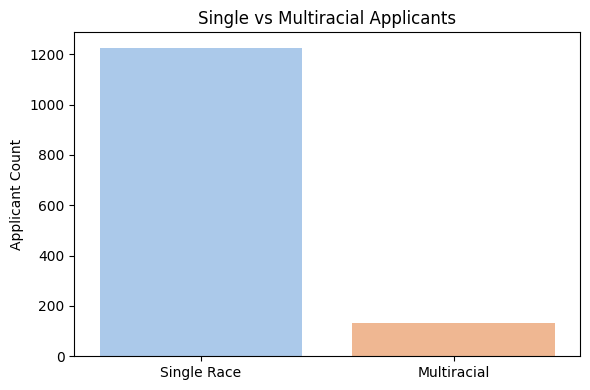

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='race_type', data=df, palette='pastel')
plt.title("Single vs Multiracial Applicants")
plt.xlabel("")
plt.ylabel("Applicant Count")
plt.tight_layout()
plt.show()


In [ ]:
df_exploded = df.explode('race_cleaned').reset_index(drop=True)

# Define the upper bound and add the capped income column
upper_cap = 500_000
df_exploded['hh_income_clipped'] = df_exploded['hh_income'].clip(upper=upper_cap)

print("✅ df_exploded ready:", df_exploded.shape)
df_exploded[['race_cleaned', 'hh_income_clipped']].head()


✅ df_exploded ready: (1504, 42)


,race_cleaned,hh_income_clipped
0,White,46000.00
1,White,46000.00
2,Black or African American,92700.00
3,Black or African American,8000.00
4,White,75370.88


C:\Users\rohan\AppData\Local\Temp\ipykernel_38944\1765716966.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


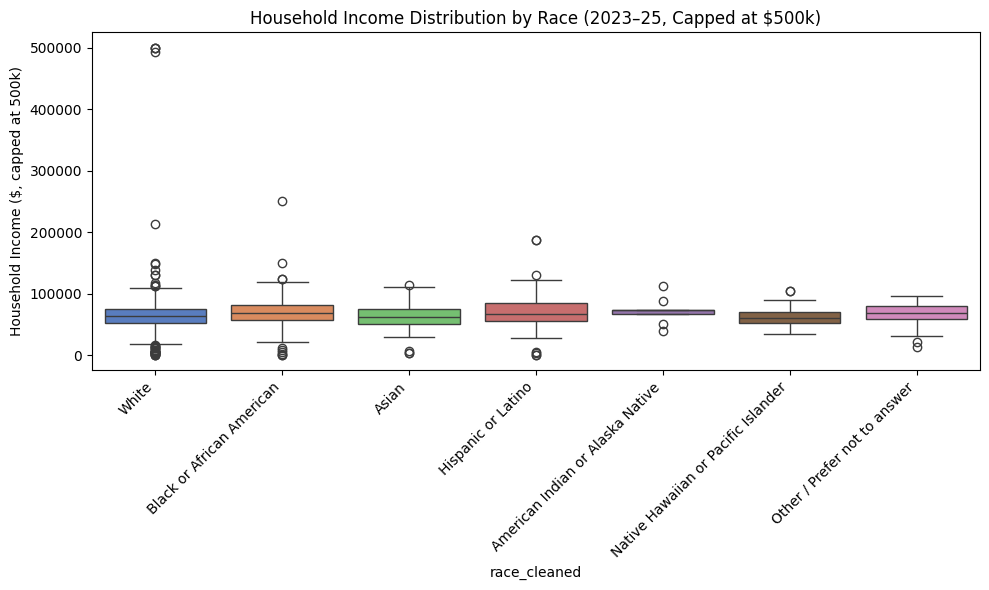

In [13]:
# Define a reasonable upper bound (e.g., $500,000 household income)
upper_cap = 500_000

df_exploded['hh_income_clipped'] = df_exploded['hh_income'].clip(upper=upper_cap)

plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_exploded,
    x='race_cleaned', y='hh_income_clipped',
    order=['White', 'Black or African American', 'Asian', 
           'Hispanic or Latino', 'American Indian or Alaska Native',
           'Native Hawaiian or Pacific Islander', 'Other / Prefer not to answer'],
    palette='muted'
)
plt.title('Household Income Distribution by Race (2023–25, Capped at $500k)')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Household Income ($, capped at 500k)")
plt.tight_layout()
plt.show()


In [14]:
df_exploded.groupby('race_cleaned')['hh_income'].describe(percentiles=[.25,.5,.75])


,count,mean,std,min,25%,50%,75%,max
race_cleaned,,,,,,,,
American Indian or Alaska Native,9.0,71353.848889,2.127668e+04,38400.00,66142.3200,73500.000,73500.0,113000.00
Asian,187.0,63452.472834,2.008195e+04,3000.00,50382.5000,62000.000,75100.0,114350.53
Black or African American,274.0,69801.509416,2.350795e+04,70.00,56205.2175,68000.000,81587.5,250000.00
Hispanic or Latino,201.0,68983.155473,2.453312e+04,100.00,55000.0000,66040.000,84000.0,187000.00
Native Hawaiian or Pacific Islander,49.0,63063.527551,1.643390e+04,35000.00,51820.0000,60000.000,70640.0,104000.00
Other / Prefer not to answer,54.0,67768.550926,1.847428e+04,13149.84,58000.0000,67849.760,79012.5,96610.00
White,724.0,162483.909959,2.606936e+06,78.00,52159.9000,63565.405,75000.0,70200405.00
